<a href="https://colab.research.google.com/github/Ygor-RR/mvp-machine-learning-analytics/blob/main/MVP_YgorRodrigues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP: Machine Learning & Analytics
**Aluno:** Ygor Ribeiro Rodrigues  
**Curso:** Machine Learning & Analytics (40530010056_20260_01)  
**Problema:** Predição de churn

---

# Descrição do problema

O churn (cancelamento de clientes) representa um dos principais desafios para empresas de telecomunicações. A perda de clientes impacta diretamente a receita da empresa e aumenta os custos de aquisição de novos consumidores.

Neste contexto, é importante identificar previamente quais clientes apresentam maior probabilidade de cancelar seus serviços, permitindo a adoção de estratégias de retenção mais eficientes.

Os principais interessados nesta solução são as equipes de marketing, relacionamento com clientes e gestão comercial, que podem utilizar as previsões para direcionar ações preventivas.

Este problema é relevante porque reduzir a taxa de churn contribui para o aumento da receita e da satisfação dos clientes.

# Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning capazes de prever a probabilidade de cancelamento de clientes (churn) a partir de informações demográficas, contratuais e de utilização dos serviços.

Serão comparados diferentes modelos de classificação, incluindo uma abordagem baseline, buscando identificar a alternativa com melhor desempenho preditivo.

# Tipo de problema

Tipo escolhido: Classificação

Justificativa:

O objetivo é prever uma variável categórica binária (Churn), indicando se um cliente irá cancelar o serviço (Yes) ou permanecer ativo (No).

Como existem exemplos históricos rotulados, o problema caracteriza-se como uma tarefa de aprendizado supervisionado de classificação binária.

# Premissas, hipóteses e critérios de sucesso

### Hipóteses

1. Clientes com menor tempo de permanência (tenure) possuem maior probabilidade de churn.

2. Clientes com contratos mensais apresentam maior risco de cancelamento do que clientes com contratos de longo prazo.

3. Valores mais elevados de cobrança mensal podem estar associados a maiores taxas de cancelamento.

### Critérios de sucesso

**Métrica principal: F1-Score.**

Neste MVP, o F1-Score foi escolhido como métrica principal devido ao equilíbrio que ele oferece entre a Precisão (Precision) e a Sensibilidade (Recall), sendo especialmente útil em problemas onde as classes podem apresentar algum desbalanceamento.

Para a empresa de telecomunicação, existem dois tipos de erros custosos:

Falso Negativo (O pior erro): O modelo diz que o cliente não vai sair, mas ele sai. Aqui a empresa perde a receita do cliente e tem um alto custo para conquistar um novo (perda de oportunidade de retenção).

Falso Positivo: O modelo diz que o cliente vai sair, mas ele não ia. Aqui a empresa gasta recursos enviando uma promoção ou bônus de retenção para alguém que já estava fiel (custo de campanha desnecessário).

Como o objetivo é ser eficiente na retenção sem desperdiçar recursos de marketing, o F1-Score é a métrica ideal, pois ele penaliza modelos que pendem demais para apenas um desses erros.

Um F1-Score alto garante que o modelo identifica bem os clientes em risco (Recall) sem disparar alarmes falsos em excesso (Precisão).


**Métricas complementares: Accuracy, Precision, Recall e ROC-AUC.**

**Resultado mínimo esperado:** O modelo final será considerado satisfatório caso apresente F1-Score superior ao baseline e capacidade de generalização em dados de teste.

Restrição prática: modelo com tempo de treinamento reduzido e fácil interpretação dos resultados.

# Ambiente, bibliotecas e reprodutibilidade

Nesta seção são importadas as bibliotecas necessárias para o desenvolvimento do MVP e definidas configurações de reprodutibilidade. A utilização de uma seed fixa garante que os resultados obtidos possam ser reproduzidos em diferentes execuções do notebook.

#### Bibliotecas utilizadas

- Pandas: manipulação dos dados.
- NumPy: operações numéricas.
- Matplotlib e Seaborn: visualização de dados.
- Scikit-Learn: preparação dos dados, treinamento e avaliação dos modelos.

In [1]:
import pandas as pd
import numpy as np
import random
import warnings
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_selector

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import xgboost
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f"Seed utilizada: {SEED}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"XGBoost: {xgboost.__version__}")

Seed utilizada: 42
Pandas: 2.2.2
NumPy: 2.0.2
XGBoost: 3.2.0


# Apresentação do Dataset e dos Dados
Carga do dataset via URL pública.

### Fonte dos Dados

O dataset utilizado é o Telco Customer Churn Dataset, amplamente empregado em problemas de previsão de evasão de clientes (churn prediction). A base contém 7.043 registros e 21 atributos relacionados ao perfil, serviços contratados e histórico de clientes de telecomunicações.

A escolha do dataset ocorreu por apresentar um problema real de negócio, com impacto direto na retenção de clientes e receita da empresa.

O dataset é originalmente disponibilizado no Kaggle e foi carregado neste projeto através de uma URL pública hospedada no GitHub, garantindo a reprodutibilidade da execução.

Limitações: os dados representam apenas um contexto específico de telecomunicações e podem não generalizar para outros setores.

Fonte:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [2]:
url = "https://raw.githubusercontent.com/Ygor-RR/mvp-machine-learning-analytics/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Carga do dataset
dataset = pd.read_csv(url)

# Exibição das primeiras linhas
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
# Verificação inicial do tamanho da base de dados para entender a escala do problema.
print(f"Linhas: {dataset.shape[0]}")
print(f"Colunas: {dataset.shape[1]}")

Linhas: 7043
Colunas: 21


O dataset possui 7.043 observações e 21 atributos. A variável alvo é Churn, indicando se o cliente cancelou ou não o serviço.

In [5]:
# Nesta etapa, analisamos se os tipos atribuídos pelo Pandas correspondem à natureza real das variáveis e se existem valores nulos óbvios.

dataset.info() # Verifica Dtypes e presença de valores nulos (non-null)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Observação: A coluna TotalCharges está como object (string), mas deveria ser numérica. Isso indica que há caracteres não numéricos (como espaços vazios) que precisarão de tratamento na fase de preparação.

In [6]:
# Resumo estatístico das variáveis numéricas originais para identificar escalas, médias e possíveis outliers
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Análise: A média do tenure (tempo de permanência) é de aproximadamente 32 meses, com um desvio padrão alto (24), o que indica grande variação no tempo de casa dos clientes.

# Análise Exploratória (EDA)

In [7]:
dataset.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
(dataset == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


A inspeção identificou 11 registros contendo espaços vazios na variável TotalCharges. Como essa variável representa o valor total gasto pelo cliente, ela deveria ser numérica. Esses registros serão convertidos para valores ausentes (NaN) e tratados na etapa de preparação dos dados.



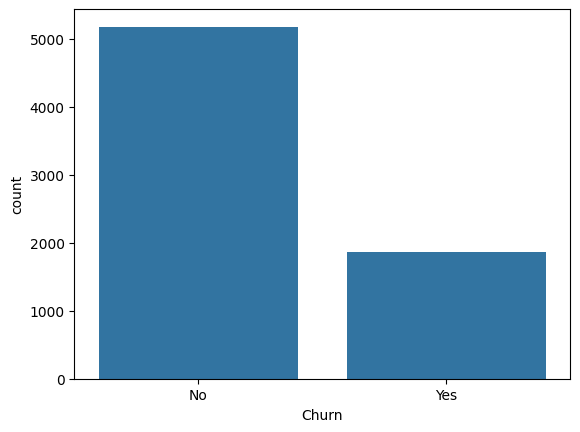

In [9]:
sns.countplot(data=dataset, x="Churn")
plt.show()

In [10]:
dataset["Churn"].value_counts(normalize=True) * 100 # Visualização em %

,proportion
Churn,
No,73.463013
Yes,26.536987


A variável alvo apresenta desbalanceamento moderado. Aproximadamente 73,5% dos clientes permaneceram na empresa, enquanto 26,5% cancelaram os serviços. Embora o desbalanceamento não seja extremo, métricas como F1-score, Recall e ROC-AUC serão consideradas além da acurácia para avaliar adequadamente os modelos.


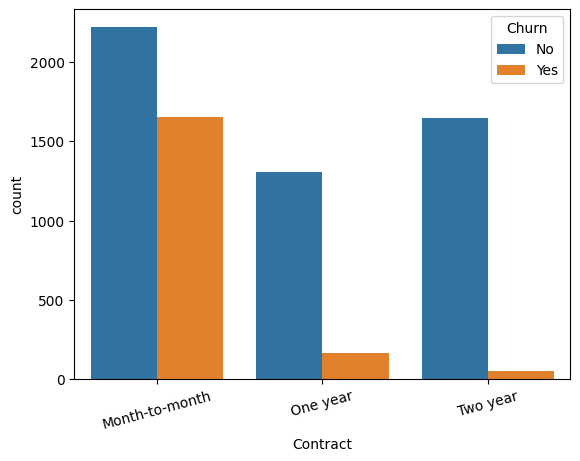

In [11]:
sns.countplot(data=dataset, x="Contract", hue="Churn")
plt.xticks(rotation=15)
plt.show()

Observa-se forte relação entre o tipo de contrato e a evasão de clientes. Contratos do tipo "Month-to-month" concentram a maior quantidade de cancelamentos, enquanto contratos anuais e, principalmente, contratos de dois anos apresentam taxas significativamente menores de churn. Essa variável aparenta possuir elevado poder preditivo para o problema.

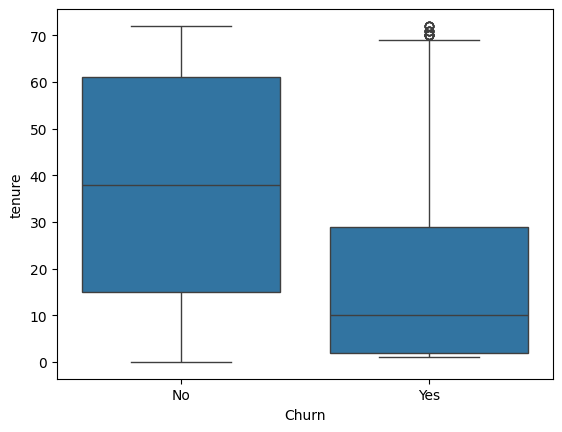

In [12]:
sns.boxplot(data=dataset, x="Churn", y="tenure")
plt.show()

Clientes que cancelaram os serviços apresentam, em média, menor tempo de permanência na empresa. Isso sugere que a probabilidade de evasão é mais elevada nos primeiros meses de relacionamento, indicando que a variável tenure pode ser uma das mais relevantes para o modelo.

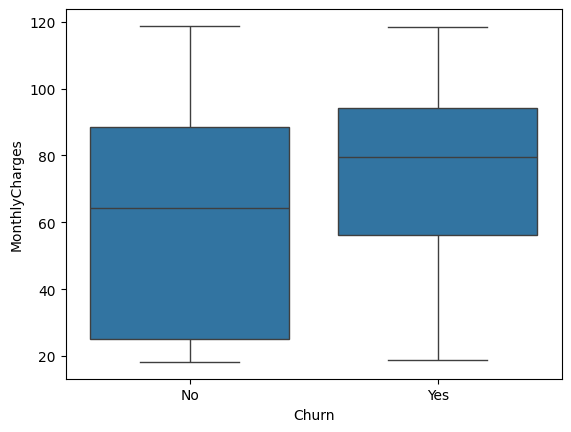

In [13]:
sns.boxplot(data=dataset, x="Churn", y="MonthlyCharges")
plt.show()

Os clientes que cancelaram os serviços apresentam valores mensais mais elevados em comparação aos clientes que permaneceram. Esse comportamento sugere que mensalidades mais altas podem estar associadas a maior probabilidade de cancelamento.

Embora existam observações extremas em tenure e MonthlyCharges (possíveis outliers), elas representam clientes reais e não erros de medição. Portanto, optou-se por mantê-las na base.

NaNs em TotalCharges (após coerção, sem imputação): 11


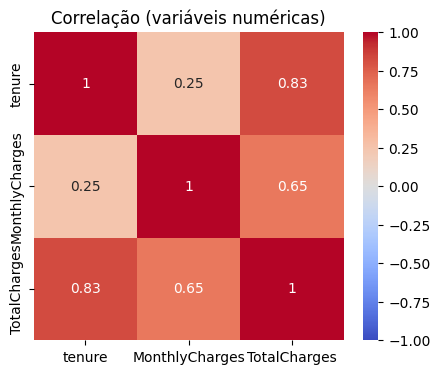

In [14]:
# Converte TotalCharges só para análise (sem escrever de volta no dataset)
totalcharges_num = pd.to_numeric(
    dataset["TotalCharges"].astype(str).str.strip().replace({"": np.nan}),
    errors="coerce"
)

# DataFrame temporário só com as 3 variáveis numéricas
tmp = dataset[["tenure", "MonthlyCharges"]].copy()
tmp["TotalCharges"] = totalcharges_num  # só no tmp

print("NaNs em TotalCharges (após coerção, sem imputação):", tmp["TotalCharges"].isna().sum())

corr = tmp.corr()  # Pearson; ignora NaNs de forma pareada

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação (variáveis numéricas)")
plt.show()

**Análise de correlação entre variáveis numéricas:**

Observa-se forte correlação positiva **entre tenure e TotalCharges** (0,83), resultado esperado: clientes com maior tempo de permanência tendem a acumular maior gasto total ao longo do relacionamento.

A correlação entre** MonthlyCharges e TotalCharges** é moderada (0,65), indicando que o valor da mensalidade também contribui para o gasto acumulado, mas não de forma determinística — clientes com mensalidades altas e baixo tenure podem ter TotalCharges menores do que clientes com mensalidades menores e alto tenure.

A correlação entre **tenure e MonthlyCharges** é baixa (0,25), sugerindo que o tempo de permanência não está diretamente associado ao valor da mensalidade contratada.

Observação: A alta correlação entre tenure e TotalCharges será considerada na etapa de preparação dos dados, pois pode introduzir multicolinearidade nos modelos lineares.

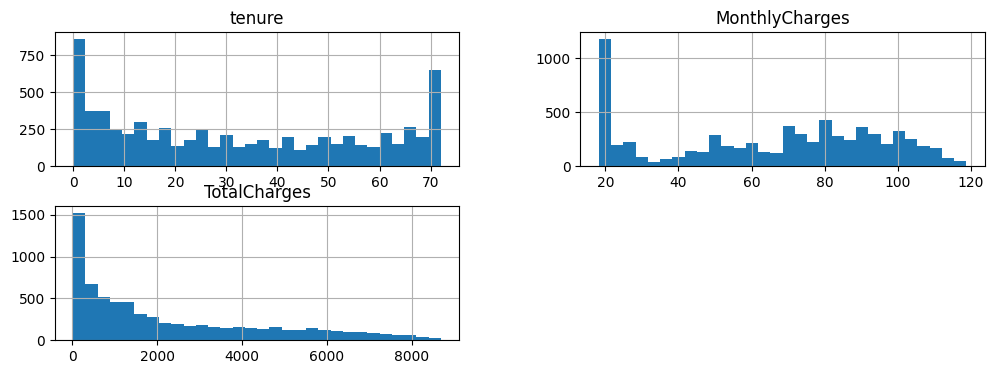

In [15]:
tmp[["tenure", "MonthlyCharges", "TotalCharges"]].hist(
    figsize=(12, 4),
    bins=30
)
plt.show()

**Análise das distribuições:**

A variável **tenure** apresenta distribuição bimodal, com concentração de clientes nos extremos — muitos clientes recém-chegados (tenure próximo de 0) e muitos clientes de longa data (tenure próximo de 72 meses). Isso reforça o padrão observado no boxplot: clientes que cancelam tendem a estar no início do relacionamento.

**MonthlyCharges** apresenta ampla variabilidade de valores, o que reforça a necessidade de padronização para modelos lineares.

**TotalCharges** apresenta forte assimetria positiva, o que é esperado dado que clientes com menor tempo de permanência naturalmente acumulam menos gasto total.

In [16]:
print(dataset["TotalCharges"].dtype)  # deve continuar como object na EDA

object


<Axes: xlabel='InternetService', ylabel='count'>

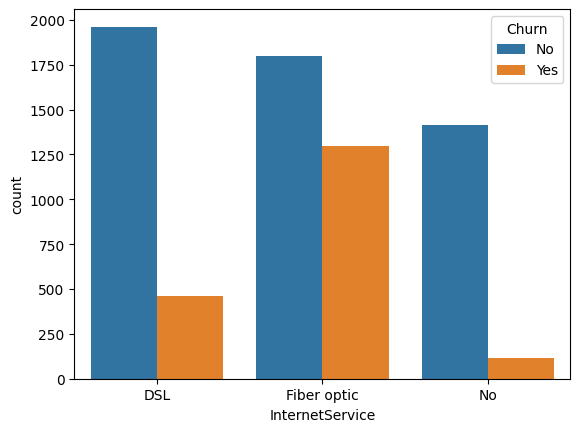

In [17]:
sns.countplot(
    data=dataset,
    x="InternetService",
    hue="Churn"
)

**Análise do tipo de serviço de internet e churn:**

O gráfico evidencia uma diferença expressiva na taxa de cancelamento conforme o tipo de serviço de internet contratado.

Clientes com Fiber optic apresentam a maior proporção de churn em relação ao total do grupo, enquanto clientes com DSL e sem serviço de internet ("No") apresentam taxas significativamente menores.

Clientes com serviço Fiber Optic apresentam maior proporção de churn. As razões para esse comportamento não podem ser determinadas apenas pela análise exploratória.

##Principais insights da EDA:


*    Clientes com contrato mensal e serviço de fibra óptica concentram a maior parte dos cancelamentos.

*   Clientes com menor tempo de permanência (tenure baixo) têm maior propensão ao churn.

*   Mensalidades mais altas estão associadas a maior taxa de cancelamento.

*   TotalCharges apresenta alta correlação com tenure, e será avaliada uma possível remoção para evitar multicolinearidade.

*   O dataset apresenta desbalanceamento moderado (~73% vs ~27%), que será considerado na escolha das métricas de avaliação.



A análise exploratória confirmou as principais hipóteses levantadas inicialmente. Clientes com menor tempo de permanência, contratos do tipo Month-to-month, mensalidades mais elevadas e serviço Fiber Optic apresentaram maior incidência de churn. Além disso, observou-se desbalanceamento moderado da variável-alvo e forte correlação entre tenure e TotalCharges, fatores que serão considerados na etapa de preparação dos dados e modelagem.

# Preparação dos dados

Nesta etapa foram realizados os tratamentos necessários para tornar os dados adequados ao treinamento dos modelos de Machine Learning.

Inicialmente, a coluna customerID foi removida por representar apenas um identificador único, sem potencial preditivo.

Em seguida, a variável-alvo Churn foi convertida para formato numérico (No -> 0, Yes -> 1), permitindo sua utilização pelos algoritmos de classificação.

Os demais tratamentos, conversão de TotalCharges de object para numérico via pd.to_numeric(..., errors='coerce') e imputação dos 11 valores ausentes pela mediana, foram incorporados diretamente ao Pipeline de pré-processamento. Essa abordagem garante que a imputação seja ajustada exclusivamente nos dados de treino e aplicada nos dados de teste, prevenindo vazamento de dados (data leakage).

A padronização das variáveis numéricas (StandardScaler) e a codificação das variáveis categóricas (OneHotEncoder) também foram realizadas dentro do Pipeline, conforme detalhado na seção seguinte.

In [18]:
# Inicialmente, removeremos a coluna da ID, já que é apenas um identificador sem poder preditivo.

dataset = dataset.drop("customerID", axis=1)

In [19]:
dataset.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [20]:
dataset["TotalCharges"].isnull().sum() # Após a imputação, não permanecem valores ausentes na base de dados.

np.int64(0)

In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Com a codificação da variável-alvo e a configuração dos tratamentos para TotalCharges e demais atributos via Pipeline, todas as variáveis encontram-se prontas para as próximas etapas de processamento.

In [22]:
# Transformar a variável alvo em numérica para que possa ser utilizada

dataset["Churn"] = dataset["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Divisão treino/teste

In [23]:
X = dataset.drop(columns=["Churn"])
y = dataset["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"Treino: {X_train.shape[0]} registros | Teste: {X_test.shape[0]} registros")

Treino: 5634 registros | Teste: 1409 registros


Foi utilizada a estratégia Holdout com divisão de 80% para treino e 20% para teste. Com 7.043 registros, essa proporção garante dados suficientes para aprendizado e avaliação confiável.

A estratificação (stratify=y) foi aplicada para preservar a proporção de ~73% / ~27% entre as classes nos dois conjuntos, evitando que o desbalanceamento distorça a avaliação.

Todas as transformações serão ajustadas apenas no treino e aplicadas no teste via Pipeline, prevenindo vazamento de dados.

# Pipeline de pré-processamento

Nesta etapa, foi construído um ColumnTransformer para automatizar o pré-processamento.

As variáveis numéricas passarão por padronização (StandardScaler), garantindo que diferentes escalas (como tenure e TotalCharges) não enviesem o modelo.

As variáveis categóricas serão convertidas via One-Hot Encoding, permitindo que algoritmos matemáticos processem informações textuais.

O uso de Pipelines evita o vazamento de dados durante a validação.

In [24]:
# Passo 1: converter TotalCharges (object → float) DENTRO do pipeline
# para evitar data leakage. O pd.to_numeric é aplicado apenas no fit,
# garantindo que nenhuma informação do teste vaze para o treino.
def coerce_total_charges(X_df):
    X_df = X_df.copy()
    X_df["TotalCharges"] = pd.to_numeric(X_df["TotalCharges"], errors="coerce")
    return X_df

coerce_tc = FunctionTransformer(coerce_total_charges, validate=False)

# Passo 2: pipelines por tipo de variável
# Numéricas: imputação pela mediana + padronização
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Categóricas: imputação pela moda + One-Hot Encoding
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

# Passo 3: ColumnTransformer unificado usando make_column_selector por dtype
# (funciona corretamente APÓS a coerção do TotalCharges)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe,      make_column_selector(dtype_include=np.number)),
        ("cat", categorical_pipe,  make_column_selector(dtype_exclude=np.number)),
    ]
)

# Baseline e modelos candidatos

In [25]:
# Baseline
baseline_pipe = Pipeline(steps=[
    ("coerce",      coerce_tc),
    ("preprocessor", preprocessor),
    ("classifier",  DummyClassifier(strategy="most_frequent"))
])

# Candidato 1: Regressão Logística
lr_pipe = Pipeline(steps=[
    ("coerce",      coerce_tc),
    ("preprocessor", preprocessor),
    ("classifier",  LogisticRegression(max_iter=2000, random_state=SEED, solver="liblinear"))
])

# Candidato 2: Random Forest
rf_pipe = Pipeline(steps=[
    ("coerce",      coerce_tc),
    ("preprocessor", preprocessor),
    ("classifier",  RandomForestClassifier(random_state=SEED))
])

# Candidato 3: XGBoost
xgb_pipe = Pipeline(steps=[
    ("coerce",      coerce_tc),
    ("preprocessor", preprocessor),
    ("classifier",  XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

In [26]:
# OTIMIZAÇÃO DE HIPERPARÂMETROS

# GridSearch: Regressão Logística
lr_param_grid = {
    "classifier__C":            [0.01, 0.1, 1.0, 10.0],
    "classifier__class_weight": [None, "balanced"]
}

lr_search = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
lr_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Tempo de treinamento (LR): {elapsed:.1f}s")
print(f"Melhores hiperparâmetros:  {lr_search.best_params_}")
print(f"Melhor F1 (CV treino):     {lr_search.best_score_:.4f}")

lr_best = lr_search.best_estimator_

# GridSearch: XGBoost
xgb_param_grid = {
    "classifier__n_estimators":  [100, 200],
    "classifier__max_depth":     [3, 5],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample":     [0.8, 1.0],
}

xgb_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
xgb_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Tempo de treinamento (XGB): {elapsed:.1f}s")
print(f"Melhores hiperparâmetros:   {xgb_search.best_params_}")
print(f"Melhor F1 (CV treino):      {xgb_search.best_score_:.4f}")

xgb_best = xgb_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Tempo de treinamento (LR): 14.5s
Melhores hiperparâmetros:  {'classifier__C': 1.0, 'classifier__class_weight': 'balanced'}
Melhor F1 (CV treino):     0.6332
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Tempo de treinamento (XGB): 29.3s
Melhores hiperparâmetros:   {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
Melhor F1 (CV treino):      0.5899


O  melhor F1 no treino foi de 0.5899.

O GridSearchCV selecionou learning_rate = 0.05 e n_estimators = 200 dentre as combinações avaliadas, indicando que um aprendizado mais gradual com maior número de árvores produziu o melhor F1 médio durante a validação cruzada.


In [27]:
# Treinamento demais modelos
baseline_pipe.fit(X_train, y_train)
lr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

print("Baseline e Modelos Candidatos treinados com sucesso!")

Baseline e Modelos Candidatos treinados com sucesso!


In [28]:
models = {
    "Baseline (DummyClassifier)": baseline_pipe,
    "Regressão Logística":        lr_best,      # ← era lr_pipe
    "Random Forest":              rf_pipe,
    "XGBoost (otimizado)":        xgb_best,
}

In [29]:
# COMPARAÇÃO TREINO vs TESTE (overfitting check)

for name, model in models.items():
    f1_tr = f1_score(y_train, model.predict(X_train))
    f1_te = f1_score(y_test,  model.predict(X_test))
    print(f"{name:<35} Treino: {f1_tr:.4f} | Teste: {f1_te:.4f} | Δ: {abs(f1_tr - f1_te):.4f}")

Baseline (DummyClassifier)          Treino: 0.0000 | Teste: 0.0000 | Δ: 0.0000
Regressão Logística                 Treino: 0.6335 | Teste: 0.6136 | Δ: 0.0199
Random Forest                       Treino: 0.9963 | Teste: 0.5321 | Δ: 0.4642
XGBoost (otimizado)                 Treino: 0.6226 | Teste: 0.5882 | Δ: 0.0343


O Random Forest apresentou forte evidência de overfitting (Δ = 0,4642), alcançando desempenho quase perfeito no conjunto de treino (F1 = 0,9963), mas apresentando queda significativa no conjunto de teste (F1 = 0,5321). Isso indica que o modelo memorizou os dados de treino sem generalizar adequadamente. Esse comportamento poderia ser mitigado com ajuste de hiperparâmetros (ex: max_depth, min_samples_leaf), o que fica como sugestão de melhoria futura.

In [30]:
models = {
    "Baseline (DummyClassifier)": baseline_pipe,
    "Regressão Logística": lr_best,
    "Random Forest": rf_pipe,
    "XGBoost (otimizado)": xgb_best,
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    y_prob = (
        model.predict_proba(X_test)[:, 1]
        if hasattr(model, "predict_proba") else None
    )

    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df)

                       Modelo  Accuracy  Precision    Recall  F1-Score  \
0  Baseline (DummyClassifier)  0.734564   0.000000  0.000000  0.000000   
1         Regressão Logística  0.738112   0.504303  0.783422  0.613613   
2               Random Forest  0.777857   0.603390  0.475936  0.532138   
3         XGBoost (otimizado)  0.806246   0.674740  0.521390  0.588235   

    ROC-AUC  
0  0.500000  
1  0.841466  
2  0.816159  
3  0.845088  


Embora o XGBoost tenha obtido os melhores valores de Accuracy (0,8062) e ROC-AUC (0,8450), a Regressão Logística apresentou o maior F1-Score (0.6136), métrica principal definida para este MVP. Dessa forma, a Regressão Logística foi considerada o melhor modelo para o problema estudado.

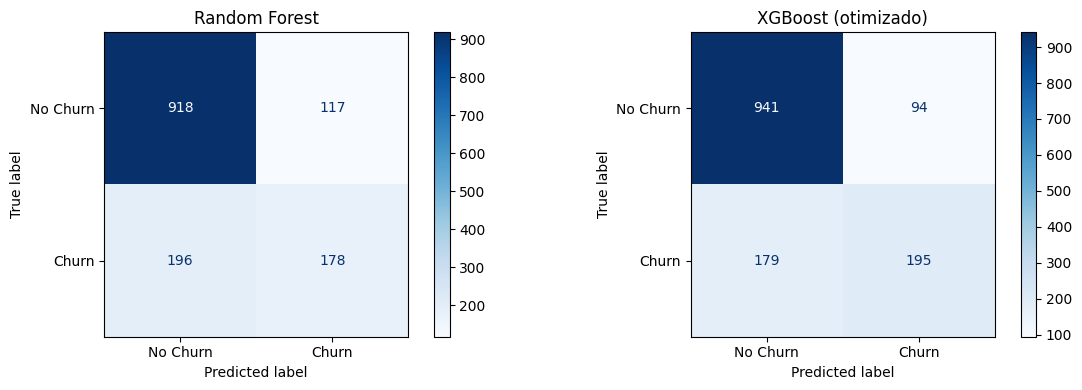

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, [
    ("Random Forest", rf_pipe),
    ("XGBoost (otimizado)", xgb_best)
]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["No Churn", "Churn"],
        cmap="Blues", ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

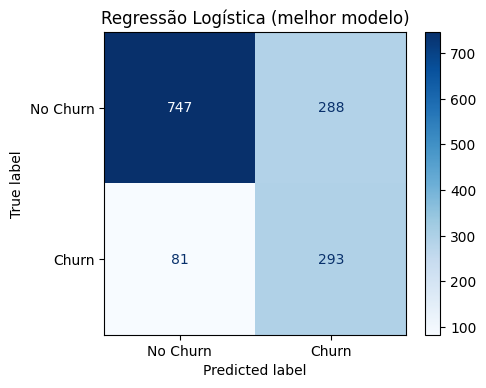

In [32]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    lr_best, X_test, y_test,
    display_labels=["No Churn", "Churn"],
    cmap="Blues", ax=ax
)
ax.set_title("Regressão Logística (melhor modelo)")
plt.tight_layout()
plt.show()

A Regressão Logística, modelo selecionado como melhor solução deste MVP, identificou corretamente 293 dos 374 casos reais de churn (Recall = 78,3%). Em contrapartida, classificou incorretamente 288 clientes que permaneceram na empresa como potenciais canceladores (falsos positivos). Esse comportamento é coerente com a escolha do F1-Score como métrica principal, priorizando a identificação de clientes em risco de evasão.

# Resumo Final:

**Problema**: Predição de churn em clientes de telecomunicações.

**Dataset**: Telco Customer Churn — 7.043 registros, 20 atributos preditivos, variável-alvo binária (Churn).

**Tratamentos realizados**: remoção de customerID, conversão e imputação de TotalCharges via Pipeline,
encoding de variáveis categóricas (One-Hot), padronização de variáveis numéricas (StandardScaler).

**Modelos avaliados**: DummyClassifier (baseline), Regressão Logística, Random Forest, XGBoost.

**Melhor modelo**: Regressão Logística (F1-Score = 0.6136 no conjunto de teste), com hiperparâmetros
C=1.0 e class_weight='balanced', otimizados via GridSearchCV.

**Justificativa**: A Regressão Logística apresentou o maior F1-Score, métrica principal
deste MVP, além de menor risco de overfitting em comparação ao Random Forest (Δ = 0,4642).

**Limitações**: desbalanceamento de classes, ausência de dados comportamentais recentes
(ex: logs de uso), e possível multicolinearidade entre tenure e TotalCharges.

**Próximos passos**: aplicar SMOTE para balanceamento, engenharia de features
(ex: proporção de gasto mensal sobre total), ajuste de hiperparâmetros do Random Forest,
e exploração de modelos de Deep Learning.